### Regression

Regression is used when the model needs to predict a continuous numerical value.

In simple words:

Regression predicts a number.

### Examples:

Predicting house price → ₦50,000,000

Predicting a student's GPA → 4.65

Predicting temperature → 31.5°C

Predicting salary → ₦500,000

Predicting sales → ₦2,000,000

### Linear Regression 
Linear Regression is a statistical model used to predict the relationship between independent and dependent variables.

### Applications of Linear Regression

* Economic Growth
* Product Price
* Housing Sales
* Score Predictions

![Screenshot 2026-09-11 075752.png](<attachment:Screenshot 2026-09-11 075752.png>)
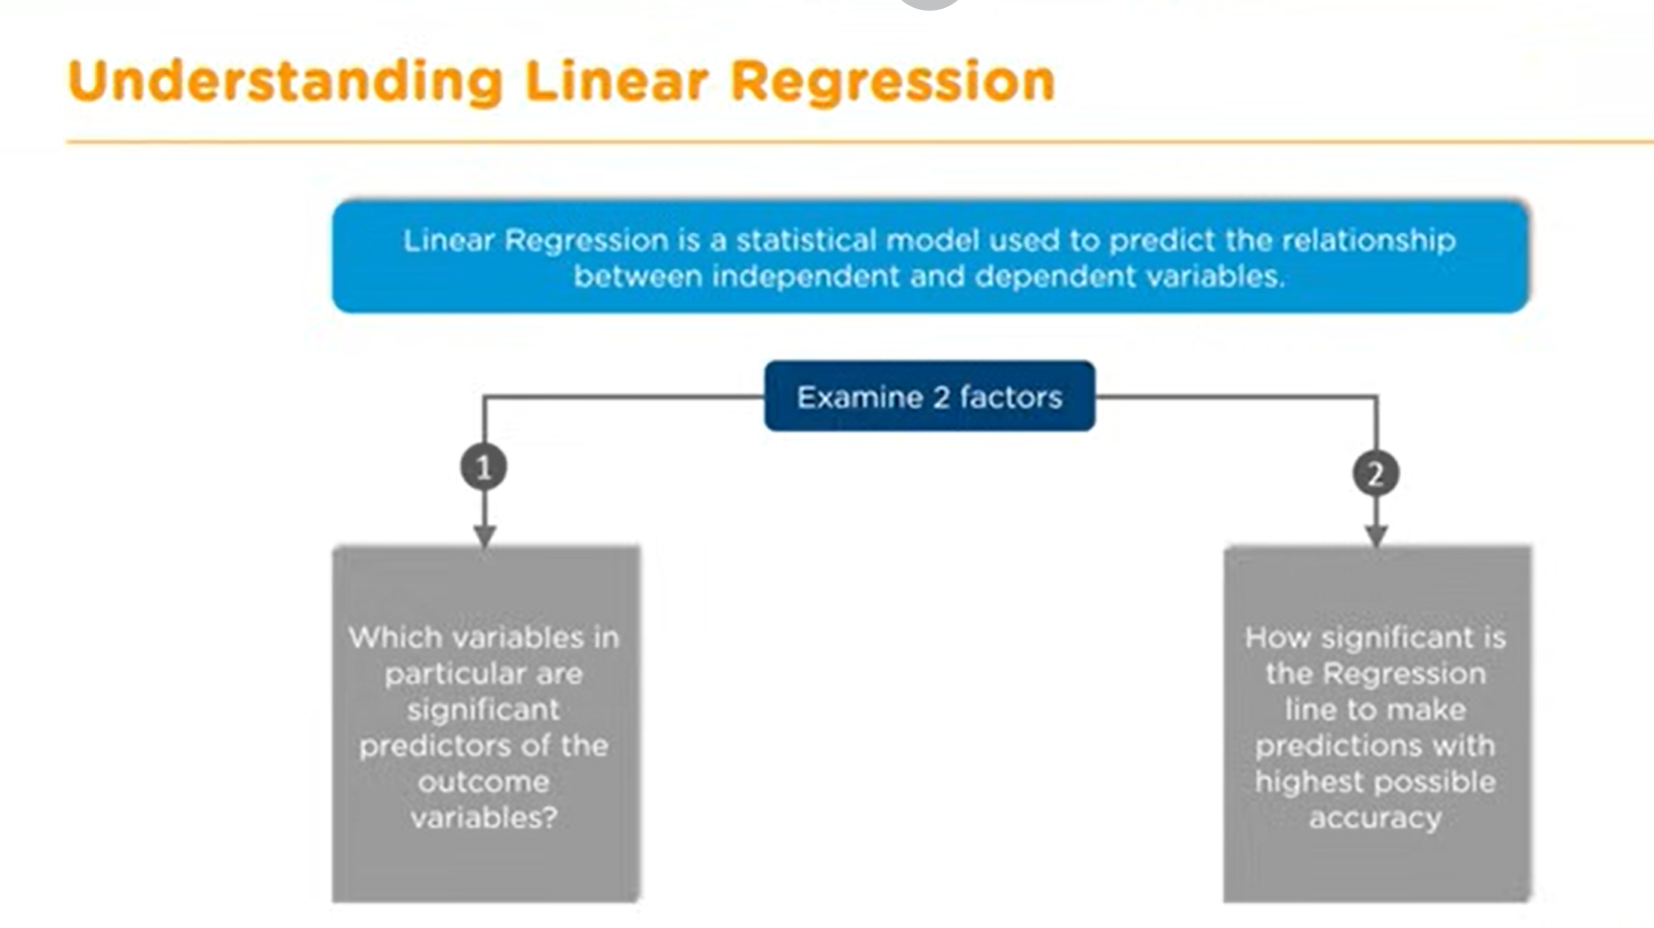

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('house_prices.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# categorical columns where missing = feature doesn't exist
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
df[none_cols] = df[none_cols].fillna('None')

# numerical columns, missing also means feature doesn't exist
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# numerical columns, missing means unrecorded (every house has this)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# categorical columns, few missing, fill with most common value
df['MasVnrType'] = df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


In [7]:
print(df.isnull().sum().sum())

0


In [8]:
# Check
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print("Remaining missing values:",len(missing_after)) 
missing_after

Remaining missing values: 0


Series([], dtype: int64)

In [9]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


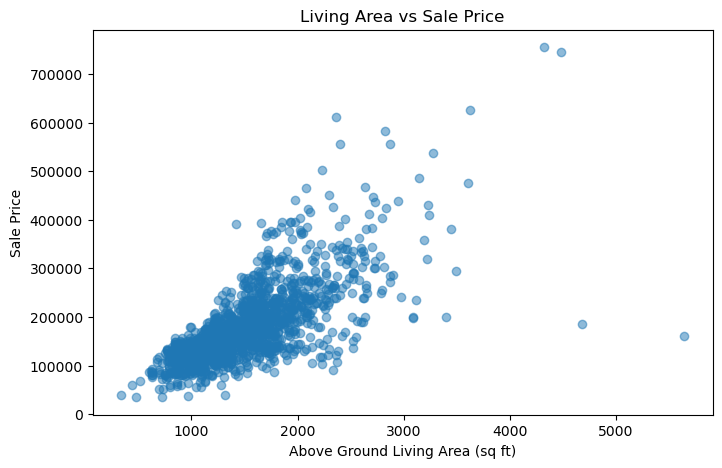

In [11]:
# visualizing the relationship between 'GrLivArea' and 'SalePrice'

plt.figure(figsize=(8,5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.title('Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.show()

In [12]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_corr = corr[1:11]

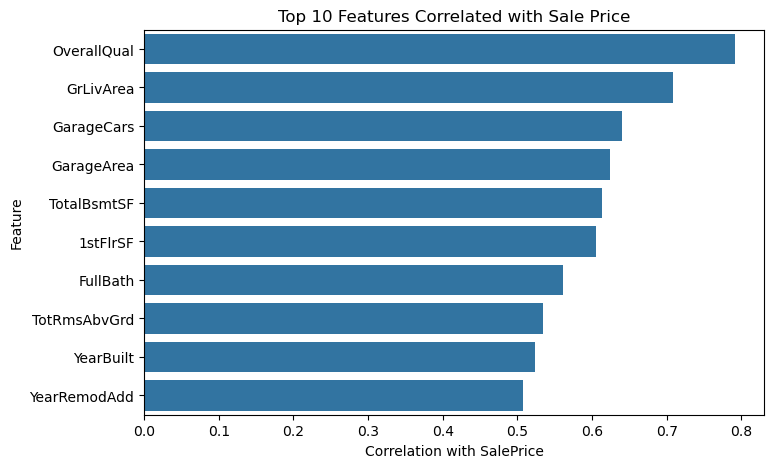

In [13]:
# Top 10 features most correlated with SalePrice
plt.figure(figsize=(8,5))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top 10 Features Correlated with Sale Price')
plt.xlabel('Correlation with SalePrice')
plt.ylabel('Feature')   # add this line to fix the "None" label
plt.show()

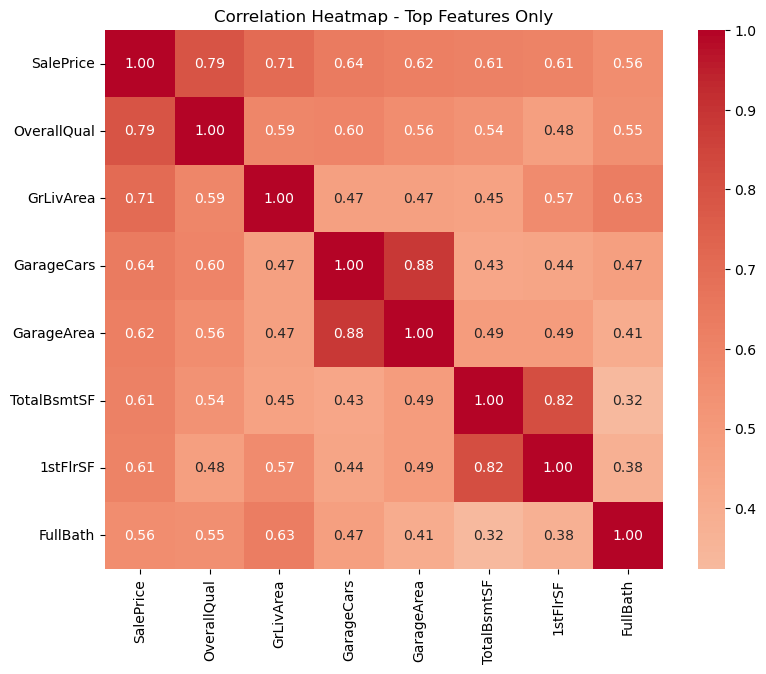

In [14]:
# correlation between the top features themselves, (helps avoid picking two features that overlap too much, like GarageCars/GarageArea)
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 
                 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath']

plt.figure(figsize=(9,7))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Top Features Only')
plt.show()

### Simple Linear Regression

Choosing X and  with ONE feature 

In [15]:

# X = feature (independent variable): living area
# y = target (dependent variable): sale price
X = df[['GrLivArea']]
y = df['SalePrice']

print(X.shape, y.shape)

(1460, 1) (1460,)


Spllitting the data

In [16]:
# Splitting data: 80% to train the model, 20% held back to test it honestly

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creating the model and Training the model

In [17]:
# Creating a Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train) # training the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Making predictions

In [18]:
# Predicting the test set results
y_pred = model.predict(X_test)  #or y_pred = model.predict(X_test)
print(y_pred[:5])        # first 5 predicted prices

print(y_test[:5].values)      # compare to actual real prices


[134357.9562804  293625.79843699 130258.39792373 195441.37579477
 190931.86160243]
[154500 325000 115000 159000 315500]


Evaluating the model

In [19]:
# Evaluating the model's performance using Mean Squared Error (MSE) and R-squared (R²) metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

r2 = r2_score(y_test, y_pred)
print("R-squared (R²):", r2)


Mean Squared Error (MSE): 3418946311.1808066
Mean Absolute Error (MAE): 38341.204476421066
R-squared (R²): 0.5542632452871117


In [20]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)  # or rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 58471.75652552954


Looking at the regression equation

In [21]:
# Calculating the coefficients and intercept of the linear regression model

# Calculating the coefficients
print("Weight (slope):", model.coef_)

# Calculating the intercept
print("Bias (intercept):", model.intercept_)


Weight (slope): [102.48895892]
Bias (intercept): 24899.74815733821


### Multiple Linear Regression

Preparing X and y with TWO features this time

In [22]:
X = df[['GrLivArea', 'OverallQual']]
y = df['SalePrice']

print(X.shape, y.shape)

(1460, 2) (1460,)


In [23]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Creating a Linear Regression model and fitting it to the training data
model2 = LinearRegression()
model2.fit(X_train, y_train) # training the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
# Predicting the test set results

y_pred2 = model2.predict(X_test)
print(y_pred2[:5])        # first 5 predicted prices

print(y_test[:5].values)      # compare to actual real prices

[153072.67955667 300706.96136415 118423.23153431 184746.96036712
 279979.56273468]
[154500 325000 115000 159000 315500]


In [26]:
# Evaluating the model's performance 
from sklearn.metrics import mean_squared_error, r2_score

mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

print("MSE:", mse2)
print("R²:", r2_2)
print("RMSE:", rmse2)

MSE: 1950070708.660199
R²: 0.7457643057171447
RMSE: 44159.604942302176


In [27]:
# Calculating the coefficients and intercept of the linear regression model

# Calculating the coefficients
print("Weight (slope):", model2.coef_)

# Calculating the intercept
print("Bias (intercept):", model2.intercept_)

Weight (slope): [   53.14476646 32523.65736394]
Bias (intercept): -98827.87520677983


Preparing X and y with THREE features this time

In [28]:
# X now has THREE features: GrLivArea, OverallQual, TotalBsmtSF

X = df[['GrLivArea', 'OverallQual', 'TotalBsmtSF']]
y = df['SalePrice']

print(X.shape, y.shape)

(1460, 3) (1460,)


In [29]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Creating a Linear Regression model and fitting it to the training data
model3 = LinearRegression()
model3.fit(X_train, y_train) # training the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
# Predicting the test set results
y_pred3 = model3.predict(X_test)
print(y_pred3[:5])        # first 5 predicted prices

print(y_test[:5].values)  # Compare to actual real prices



[156266.3813862  299325.08647267 124485.47981304 182534.90375011
 285506.65197619]
[154500 325000 115000 159000 315500]


In [32]:
# Evaluating the model's performance 
from sklearn.metrics import mean_squared_error, r2_score

mse3 = mean_squared_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)
rmse3 = np.sqrt(mse3)

print("MSE:", mse3)
print("R²:", r2_3)
print("RMSE:", rmse3)

MSE: 1667657527.1633165
R²: 0.7825832328225213
RMSE: 40836.962756347544


In [33]:
# Calculating the coefficients and intercept of the linear regression model

# Calculating the coefficients
print("Weight (slope):", model3.coef_)

# Calculating the intercept
print("Bias (intercept):", model3.intercept_)

Weight (slope): [   47.13601888 28203.61010365    33.17354342]
Bias (intercept): -98427.32987876007


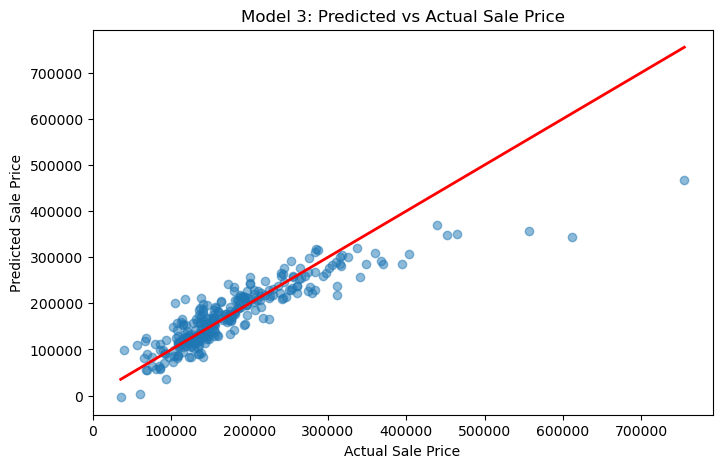

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred3, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Model 3: Predicted vs Actual Sale Price')
plt.show()

The model performs well for typical-priced homes, with predictions closely following the red line below ~$400,000. However, it consistently underpredicts higher-priced homes. This is likely because important features driving luxury pricing, such as location, unique architecture, and premium finishes, were not included in this model. Additionally, linear regression assumes each feature affects price at a constant rate, which may not hold true for expensive homes, where value is often driven by factors beyond size and general quality.

## Model Summary: Predicting House Prices with Linear Regression

Three linear regression models were built and compared, each adding one additional feature based on correlation analysis with `SalePrice`.

### Model 1: Simple Linear Regression (GrLivArea)
Using only `GrLivArea` (above-ground living area) as a single feature, the model achieved an R² of 0.554 and an RMSE of $58,472. This means living area alone explains about 55% of the variation in house prices, with predictions off by an average of roughly $58,472.

**Formula:** `SalePrice = 102.49 × GrLivArea + 24,899.75`

| Metric | Value |
|---|---|
| Weight (GrLivArea) | 102.49 |
| Bias | 24,899.75 |
| MSE | 3,418,946,311.18 |
| R² | 0.554 |
| RMSE | $58,472 |

### Model 2: Multiple Linear Regression (GrLivArea + OverallQual)
Adding `OverallQual` (overall material and finish quality, rated 1-10), the feature most strongly correlated with `SalePrice` at 0.79, improved the model substantially. R² increased to 0.746 and RMSE dropped to $44,160.

**Formula:** `SalePrice = (53.14 × GrLivArea) + (32,523.66 × OverallQual) - 98,827.88`

| Metric | Value |
|---|---|
| Weight (GrLivArea) | 53.14 |
| Weight (OverallQual) | 32,523.66 |
| Bias | -98,827.88 |
| MSE | 1,950,070,708.66 |
| R² | 0.746 |
| RMSE | $44,160 |

Note that `GrLivArea`'s weight dropped from 102.49 (alone) to 53.14 once `OverallQual` was added — the two features now share the work of explaining price, rather than `GrLivArea` carrying the full weight on its own.

### Model 3: Multiple Linear Regression (GrLivArea + OverallQual + TotalBsmtSF)
A third feature, `TotalBsmtSF` (total basement square footage), was added after confirming via a correlation heatmap that it carried distinct information from the existing features. This further improved performance to an R² of 0.783 and an RMSE of $40,837.

**Formula:** `SalePrice = (47.14 × GrLivArea) + (28,203.61 × OverallQual) + (33.17 × TotalBsmtSF) - 98,427.33`

| Metric | Value |
|---|---|
| Weight (GrLivArea) | 47.14 |
| Weight (OverallQual) | 28,203.61 |
| Weight (TotalBsmtSF) | 33.17 |
| Bias | -98,427.33 |
| MSE | 1,667,657,527.16 |
| R² | 0.783 |
| RMSE | $40,837 |

### Comparison

| Model | Features | R² | RMSE |
|---|---|---|---|
| 1 | GrLivArea | 0.554 | $58,472 |
| 2 | + OverallQual | 0.746 | $44,160 |
| 3 | + TotalBsmtSF | 0.783 | $40,837 |

### Key takeaways
- Adding features improved the model, but each new feature helped less than the last (diminishing returns).
- A feature's weight changes depending on what other features are in the model,it's not fixed.
- Checking correlation between features (not just with price) helped avoid picking two features that measure almost the same thing (e.g. `GarageCars` and `GarageArea`).
- The final model explains about 78% of house price variation using just 3 features, there's room to improve with more features or a different model type.